In [1]:
# ============================================================
# 01_dataset_setup_and_split.ipynb
# Cell 1: Drive Mount, Runtime Check, Directory Setup
# ============================================================

import os
import zipfile
from pathlib import Path

import torch
from google.colab import drive

# -----------------------------
# 1. Mount Google Drive
# -----------------------------
drive.mount("/content/drive")

# -----------------------------
# 2. Runtime check
# -----------------------------
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

# -----------------------------
# 3. Main project paths
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis/thesis_project")

ZIP_PATH = Path("/content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip")

LOCAL_DATA_ROOT = Path("/content/data")
DATASET_PATH = LOCAL_DATA_ROOT / "PlantVillage"

print("\nProject root:", PROJECT_ROOT)
print("Zip path:", ZIP_PATH)
print("Local dataset path:", DATASET_PATH)

# -----------------------------
# 4. Roadmap-based directory structure
# -----------------------------
directories = [
    PROJECT_ROOT / "data",

    PROJECT_ROOT / "01_baseline_before_optimization" / "models",
    PROJECT_ROOT / "01_baseline_before_optimization" / "notebooks",
    PROJECT_ROOT / "01_baseline_before_optimization" / "scripts",
    PROJECT_ROOT / "01_baseline_before_optimization" / "results",

    PROJECT_ROOT / "02_after_pruning_quantization" / "models",
    PROJECT_ROOT / "02_after_pruning_quantization" / "notebooks",
    PROJECT_ROOT / "02_after_pruning_quantization" / "scripts",
    PROJECT_ROOT / "02_after_pruning_quantization" / "results",

    PROJECT_ROOT / "03_final_comparison" / "notebooks",
    PROJECT_ROOT / "03_final_comparison" / "scripts",
    PROJECT_ROOT / "03_final_comparison" / "results",

    PROJECT_ROOT / "common",
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("\nDirectory structure created successfully.")

Mounted at /content/drive
PyTorch version: 2.10.0+cpu
CUDA available: False
Running on CPU

Project root: /content/drive/MyDrive/Thesis/thesis_project
Zip path: /content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip
Local dataset path: /content/data/PlantVillage

Directory structure created successfully.


In [2]:
# ============================================================
# Cell 2: Dataset Extraction
# ============================================================

# -----------------------------
# 1. Check zip file
# -----------------------------
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset zip file not found: {ZIP_PATH}")

print("Dataset zip found:", ZIP_PATH)

# -----------------------------
# 2. Create local data folder
# -----------------------------
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Extract dataset if not already extracted
# -----------------------------
if not DATASET_PATH.exists():
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(LOCAL_DATA_ROOT)
    print("Unzip complete.")
else:
    print("Dataset already extracted in Colab runtime.")

# -----------------------------
# 4. Check dataset path
# -----------------------------
print("Dataset exists:", DATASET_PATH.exists())
print("Dataset path:", DATASET_PATH)

# -----------------------------
# 5. Handle possible nested folder issue
# -----------------------------
if DATASET_PATH.exists():
    subfolders = [p for p in DATASET_PATH.iterdir() if p.is_dir()]

    if len(subfolders) == 1 and subfolders[0].name.lower() == "plantvillage":
        DATASET_PATH = subfolders[0]
        print("Nested PlantVillage folder detected.")
        print("Updated dataset path:", DATASET_PATH)

Dataset zip found: /content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip
Unzipping dataset...
Unzip complete.
Dataset exists: True
Dataset path: /content/data/PlantVillage


In [3]:
# ============================================================
# Cell 3: Dataset Audit
# ============================================================

import pandas as pd

image_extensions = {".jpg", ".jpeg", ".png"}

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset folder not found: {DATASET_PATH}")

class_dirs = sorted([p for p in DATASET_PATH.iterdir() if p.is_dir()])

rows = []
total_images = 0

for class_dir in class_dirs:
    image_files = [
        p for p in class_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ]

    rows.append({
        "class_name": class_dir.name,
        "num_images": len(image_files)
    })

    total_images += len(image_files)

class_distribution_df = pd.DataFrame(rows)

print("Total classes:", len(class_dirs))
print("Total images:", total_images)
print("Minimum images in a class:", class_distribution_df["num_images"].min())
print("Maximum images in a class:", class_distribution_df["num_images"].max())

display(class_distribution_df)

# Save class distribution
class_distribution_path = PROJECT_ROOT / "data" / "class_distribution.csv"
class_distribution_df.to_csv(class_distribution_path, index=False)

print("\nClass distribution saved at:")
print(class_distribution_path)

Total classes: 38
Total images: 54305
Minimum images in a class: 152
Maximum images in a class: 5507


,class_name,num_images
0,Apple___Apple_scab,630
1,Apple___Black_rot,621
2,Apple___Cedar_apple_rust,275
3,Apple___healthy,1645
4,Blueberry___healthy,1502
5,Cherry_(including_sour)___Powdery_mildew,1052
6,Cherry_(including_sour)___healthy,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,513
8,Corn_(maize)___Common_rust_,1192
9,Corn_(maize)___Northern_Leaf_Blight,985



Class distribution saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/class_distribution.csv


In [4]:
# ============================================================
# Cell 4: Image Size and Color Mode Audit
# ============================================================

from PIL import Image
from tqdm import tqdm

image_files = [
    p for p in DATASET_PATH.rglob("*")
    if p.suffix.lower() in image_extensions
]

print("Total image files found:", len(image_files))

size_rows = []

for img_path in tqdm(image_files, desc="Checking image sizes and modes"):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode

        file_size_kb = os.path.getsize(img_path) / 1024

        size_rows.append({
            "relative_path": str(img_path.relative_to(DATASET_PATH)),
            "class_name": img_path.parent.name,
            "file_name": img_path.name,
            "width": width,
            "height": height,
            "aspect_ratio": round(width / height, 4),
            "mode": mode,
            "file_size_kb": round(file_size_kb, 2),
            "error": ""
        })

    except Exception as error:
        size_rows.append({
            "relative_path": str(img_path.relative_to(DATASET_PATH)),
            "class_name": img_path.parent.name,
            "file_name": img_path.name,
            "width": None,
            "height": None,
            "aspect_ratio": None,
            "mode": None,
            "file_size_kb": None,
            "error": str(error)
        })

image_size_df = pd.DataFrame(size_rows)

print("\nTotal checked images:", len(image_size_df))

print("\nUnique image sizes:")
unique_sizes_df = (
    image_size_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(unique_sizes_df)

print("\nColor modes:")
display(image_size_df["mode"].value_counts())

print("\nErrors:")
display(image_size_df[image_size_df["error"] != ""])

# Save image size report
image_size_report_path = PROJECT_ROOT / "data" / "image_size_report.csv"
image_size_df.to_csv(image_size_report_path, index=False)

print("\nImage size report saved at:")
print(image_size_report_path)

Total image files found: 54305


Checking image sizes and modes: 100%|██████████| 54305/54305 [00:12<00:00, 4203.37it/s]



Total checked images: 54305

Unique image sizes:


,width,height,count
0,256,256,54305



Color modes:


,count
mode,
RGB,54304
RGBA,1



Errors:


,relative_path,class_name,file_name,width,height,aspect_ratio,mode,file_size_kb,error



Image size report saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/image_size_report.csv


In [5]:
# ============================================================
# Cell 5: Create Label Map and All Files List
# ============================================================

class_dirs = sorted([p for p in DATASET_PATH.iterdir() if p.is_dir()])
class_to_idx = {class_dir.name: idx for idx, class_dir in enumerate(class_dirs)}

all_rows = []

for class_dir in class_dirs:
    class_name = class_dir.name
    label = class_to_idx[class_name]

    image_files = sorted([
        p for p in class_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])

    for img_path in image_files:
        all_rows.append({
            "relative_path": str(img_path.relative_to(DATASET_PATH)),
            "class_name": class_name,
            "label": label
        })

df_all = pd.DataFrame(all_rows)

label_map_df = pd.DataFrame([
    {
        "class_name": class_name,
        "label": label
    }
    for class_name, label in class_to_idx.items()
])

print("Total images in all files list:", len(df_all))
print("Total classes:", df_all["class_name"].nunique())

display(label_map_df)

# Save files
all_files_path = PROJECT_ROOT / "data" / "all_files.csv"
label_map_path = PROJECT_ROOT / "data" / "label_map.csv"

df_all.to_csv(all_files_path, index=False)
label_map_df.to_csv(label_map_path, index=False)

print("\nAll files CSV saved at:")
print(all_files_path)

print("\nLabel map CSV saved at:")
print(label_map_path)

Total images in all files list: 54305
Total classes: 38


,class_name,label
0,Apple___Apple_scab,0
1,Apple___Black_rot,1
2,Apple___Cedar_apple_rust,2
3,Apple___healthy,3
4,Blueberry___healthy,4
5,Cherry_(including_sour)___Powdery_mildew,5
6,Cherry_(including_sour)___healthy,6
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,7
8,Corn_(maize)___Common_rust_,8
9,Corn_(maize)___Northern_Leaf_Blight,9



All files CSV saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/all_files.csv

Label map CSV saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/label_map.csv


In [6]:
# ============================================================
# Cell 6: Stratified Split: 75% Train, 15% Validation, 10% Test
# ============================================================

from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Check required dataframe
# -----------------------------
print("Total images before split:", len(df_all))
print("Total classes before split:", df_all["class_name"].nunique())

# -----------------------------
# 2. First split: 75% train, 25% temporary
# -----------------------------
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.25,
    stratify=df_all["label"],
    random_state=42
)

# -----------------------------
# 3. Second split: temporary data into validation and test
# Temporary data = 25% of total dataset
# Validation = 15% of total dataset
# Test = 10% of total dataset
# Therefore, test size inside temporary data = 10 / 25 = 0.40
# -----------------------------
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.40,
    stratify=temp_df["label"],
    random_state=42
)

# -----------------------------
# 4. Reset index
# -----------------------------
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# -----------------------------
# 5. Print split summary
# -----------------------------
print("\nSplit summary:")
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

print("\nClass check:")
print("Train classes:", train_df["class_name"].nunique())
print("Validation classes:", val_df["class_name"].nunique())
print("Test classes:", test_df["class_name"].nunique())

# -----------------------------
# 6. Overlap check
# -----------------------------
train_paths = set(train_df["relative_path"])
val_paths = set(val_df["relative_path"])
test_paths = set(test_df["relative_path"])

train_val_overlap = len(train_paths.intersection(val_paths))
train_test_overlap = len(train_paths.intersection(test_paths))
val_test_overlap = len(val_paths.intersection(test_paths))

print("\nOverlap check:")
print("Train-Val overlap:", train_val_overlap)
print("Train-Test overlap:", train_test_overlap)
print("Val-Test overlap:", val_test_overlap)

assert train_val_overlap == 0, "Train and validation sets overlap!"
assert train_test_overlap == 0, "Train and test sets overlap!"
assert val_test_overlap == 0, "Validation and test sets overlap!"

print("\nNo overlap found. Split is clean.")

Total images before split: 54305
Total classes before split: 38

Split summary:
Train images: 40728
Validation images: 8146
Test images: 5431

Class check:
Train classes: 38
Validation classes: 38
Test classes: 38

Overlap check:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

No overlap found. Split is clean.


In [7]:
# ============================================================
# Cell 7: Save Split CSV Files
# ============================================================

train_files_path = PROJECT_ROOT / "data" / "train_files.csv"
val_files_path = PROJECT_ROOT / "data" / "val_files.csv"
test_files_path = PROJECT_ROOT / "data" / "test_files.csv"

train_df.to_csv(train_files_path, index=False)
val_df.to_csv(val_files_path, index=False)
test_df.to_csv(test_files_path, index=False)

print("Train files saved at:")
print(train_files_path)

print("\nValidation files saved at:")
print(val_files_path)

print("\nTest files saved at:")
print(test_files_path)

print("\nSaved file check:")
print("train_files.csv exists:", train_files_path.exists())
print("val_files.csv exists:", val_files_path.exists())
print("test_files.csv exists:", test_files_path.exists())

Train files saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/train_files.csv

Validation files saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/val_files.csv

Test files saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/test_files.csv

Saved file check:
train_files.csv exists: True
val_files.csv exists: True
test_files.csv exists: True


In [8]:
# ============================================================
# Cell 8: Split Class Distribution
# ============================================================

split_distribution_df = pd.DataFrame({
    "class_name": sorted(df_all["class_name"].unique())
})

train_counts = train_df["class_name"].value_counts()
val_counts = val_df["class_name"].value_counts()
test_counts = test_df["class_name"].value_counts()

split_distribution_df["train_count"] = (
    split_distribution_df["class_name"]
    .map(train_counts)
    .fillna(0)
    .astype(int)
)

split_distribution_df["val_count"] = (
    split_distribution_df["class_name"]
    .map(val_counts)
    .fillna(0)
    .astype(int)
)

split_distribution_df["test_count"] = (
    split_distribution_df["class_name"]
    .map(test_counts)
    .fillna(0)
    .astype(int)
)

split_distribution_df["total_count"] = (
    split_distribution_df["train_count"] +
    split_distribution_df["val_count"] +
    split_distribution_df["test_count"]
)

display(split_distribution_df)

split_distribution_path = PROJECT_ROOT / "data" / "split_class_distribution.csv"
split_distribution_df.to_csv(split_distribution_path, index=False)

print("Split class distribution saved at:")
print(split_distribution_path)

print("\nTotal check:")
print("Train total:", split_distribution_df["train_count"].sum())
print("Validation total:", split_distribution_df["val_count"].sum())
print("Test total:", split_distribution_df["test_count"].sum())
print("Overall total:", split_distribution_df["total_count"].sum())

,class_name,train_count,val_count,test_count,total_count
0,Apple___Apple_scab,473,94,63,630
1,Apple___Black_rot,466,93,62,621
2,Apple___Cedar_apple_rust,206,41,28,275
3,Apple___healthy,1234,246,165,1645
4,Blueberry___healthy,1126,226,150,1502
5,Cherry_(including_sour)___Powdery_mildew,789,158,105,1052
6,Cherry_(including_sour)___healthy,641,128,85,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,385,77,51,513
8,Corn_(maize)___Common_rust_,894,179,119,1192
9,Corn_(maize)___Northern_Leaf_Blight,739,148,98,985


Split class distribution saved at:
/content/drive/MyDrive/Thesis/thesis_project/data/split_class_distribution.csv

Total check:
Train total: 40728
Validation total: 8146
Test total: 5431
Overall total: 54305


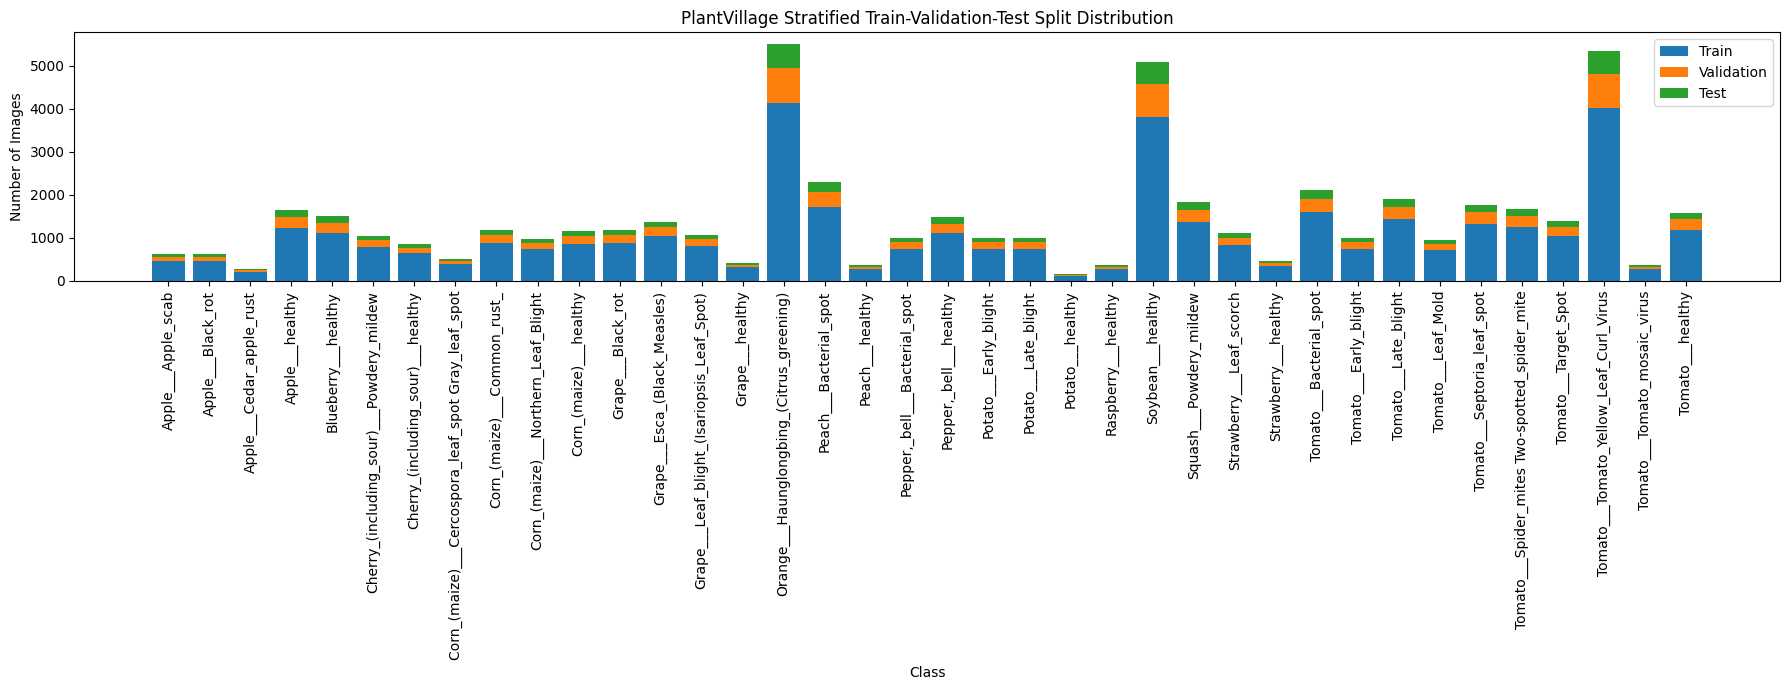

In [9]:
# ============================================================
# Cell 9: Visualize Split Distribution
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18, 7))

x = range(len(split_distribution_df))

plt.bar(
    x,
    split_distribution_df["train_count"],
    label="Train"
)

plt.bar(
    x,
    split_distribution_df["val_count"],
    bottom=split_distribution_df["train_count"],
    label="Validation"
)

plt.bar(
    x,
    split_distribution_df["test_count"],
    bottom=split_distribution_df["train_count"] + split_distribution_df["val_count"],
    label="Test"
)

plt.xticks(x, split_distribution_df["class_name"], rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("PlantVillage Stratified Train-Validation-Test Split Distribution")
plt.legend()
plt.tight_layout()
plt.show()

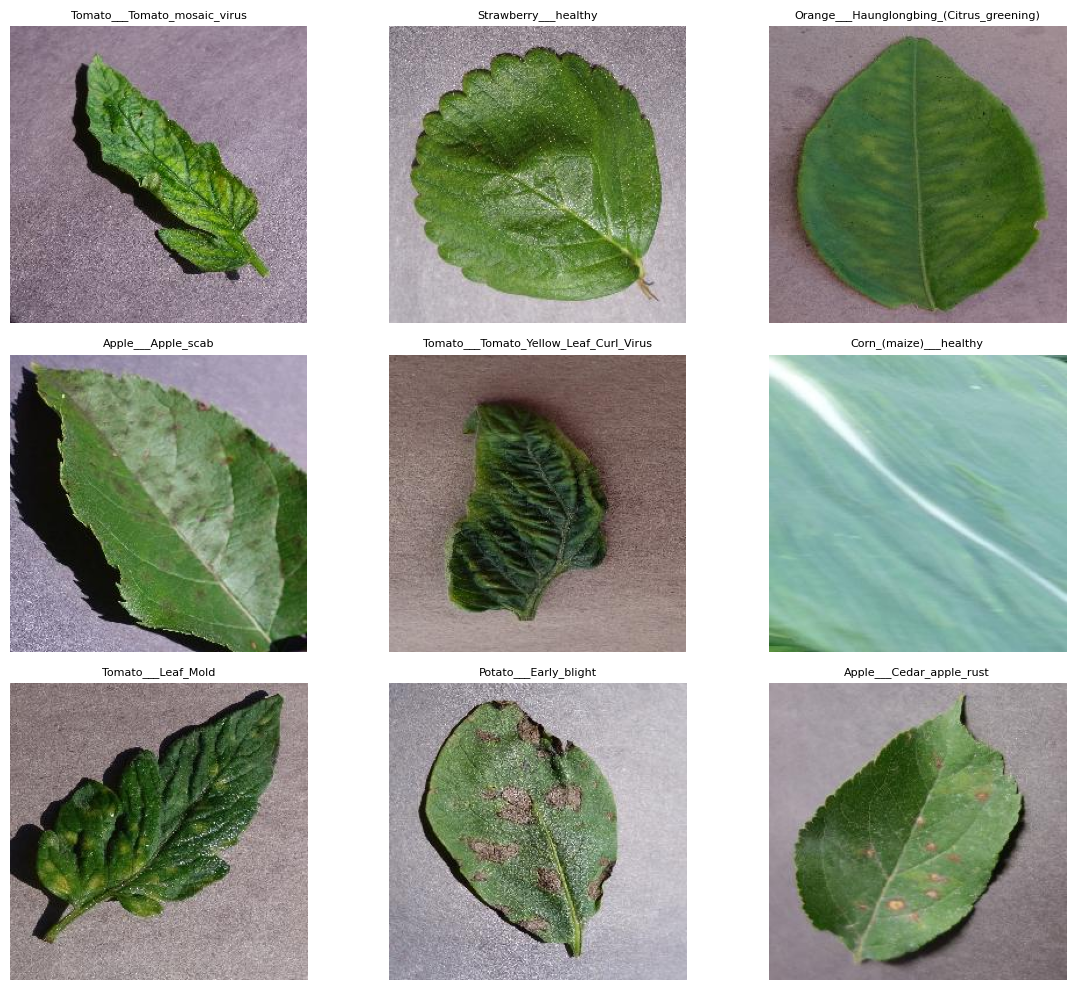

In [10]:
# ============================================================
# Cell 10: Display Sample Images
# ============================================================

import random
from PIL import Image
import matplotlib.pyplot as plt

# Select 9 random classes
sample_classes = random.sample(class_dirs, min(9, len(class_dirs)))

plt.figure(figsize=(12, 10))

for i, class_dir in enumerate(sample_classes):
    image_files = [
        p for p in class_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ]

    if len(image_files) == 0:
        continue

    img_path = random.choice(image_files)

    # Important: Convert all images to RGB
    img = Image.open(img_path).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_dir.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Cell 11: Final Verification
# ============================================================

required_files = [
    PROJECT_ROOT / "data" / "class_distribution.csv",
    PROJECT_ROOT / "data" / "image_size_report.csv",
    PROJECT_ROOT / "data" / "all_files.csv",
    PROJECT_ROOT / "data" / "label_map.csv",
    PROJECT_ROOT / "data" / "train_files.csv",
    PROJECT_ROOT / "data" / "val_files.csv",
    PROJECT_ROOT / "data" / "test_files.csv",
    PROJECT_ROOT / "data" / "split_class_distribution.csv",
]

print("Final verification:\n")

all_ok = True

for file_path in required_files:
    exists = file_path.exists()
    print(file_path.name, "->", exists)

    if not exists:
        all_ok = False

print("\nProject data folder:")
for item in sorted((PROJECT_ROOT / "data").iterdir()):
    print(item.name)

if all_ok:
    print("\nNotebook 01 completed successfully.")
else:
    print("\nSome files are missing. Please check the missing files above.")

Final verification:

class_distribution.csv -> True
image_size_report.csv -> True
all_files.csv -> True
label_map.csv -> True
train_files.csv -> True
val_files.csv -> True
test_files.csv -> True
split_class_distribution.csv -> True

Project data folder:
all_files.csv
class_distribution.csv
image_size_report.csv
label_map.csv
split_class_distribution.csv
test_files.csv
train_files.csv
val_files.csv

Notebook 01 completed successfully.
